In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [2]:
paths = [
    Path("dataset/processed/student_performance_final.csv"),
    Path("../dataset/processed/student_performance_final.csv"),
    Path(r"D:\adaptive-quiz-system\dataset\processed\student_performance_final.csv"),
]

dataset_path = next((p for p in paths if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError("Cleaned dataset not found. Run 01_data_cleaning.ipynb first")

df = pd.read_csv(dataset_path)
print("Dataset loaded:", dataset_path)
print("Shape:", df.shape)

Dataset loaded: ..\dataset\processed\student_performance_final.csv
Shape: (2392, 15)


In [3]:
X = df.drop(columns=["StudentID", "GradeClass", "GPA"])
y = df["GradeClass"]

print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']
Target: GradeClass


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1913, 12)
Testing data: (479, 12)


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}
predictions = {}

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")

    results[name] = {
        "Train Accuracy": accuracy_score(y_train, model.predict(X_train)),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "CV Accuracy": cv_scores.mean(),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "Macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
    }
    predictions[name] = y_pred

    print(name, "trained successfully!")
    print("Accuracy:", round(results[name]["Test Accuracy"] * 100, 2), "%")
    print()
    print(classification_report(y_test, y_pred, zero_division=0))

### Logistic Regression

In [6]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

evaluate_model("Logistic Regression", logistic_model)

Logistic Regression trained successfully!
Accuracy: 72.65 %

              precision    recall  f1-score   support

           0       0.33      0.14      0.20        21
           1       0.55      0.43      0.48        54
           2       0.50      0.68      0.58        78
           3       0.59      0.47      0.52        83
           4       0.90      0.95      0.92       243

    accuracy                           0.73       479
   macro avg       0.57      0.53      0.54       479
weighted avg       0.72      0.73      0.71       479



### Decision Tree

In [7]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)

evaluate_model("Decision Tree", tree_model)

Decision Tree trained successfully!
Accuracy: 69.1 %

              precision    recall  f1-score   support

           0       0.60      0.14      0.23        21
           1       0.55      0.52      0.53        54
           2       0.48      0.62      0.54        78
           3       0.43      0.43      0.43        83
           4       0.91      0.89      0.90       243

    accuracy                           0.69       479
   macro avg       0.59      0.52      0.53       479
weighted avg       0.70      0.69      0.69       479



### Random Forest

In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

evaluate_model("Random Forest", rf_model)

Random Forest trained successfully!
Accuracy: 71.4 %

              precision    recall  f1-score   support

           0       0.36      0.19      0.25        21
           1       0.52      0.41      0.46        54
           2       0.51      0.65      0.57        78
           3       0.52      0.53      0.52        83
           4       0.92      0.91      0.91       243

    accuracy                           0.71       479
   macro avg       0.57      0.54      0.54       479
weighted avg       0.71      0.71      0.71       479



In [9]:
results_df = pd.DataFrame(results).T.round(4)
results_df.index.name = "Model"

results_df

,Train Accuracy,Test Accuracy,CV Accuracy,Precision,Recall,F1 Score,Macro F1
Model,,,,,,,
Logistic Regression,0.7433,0.7265,0.7130,0.7159,0.7265,0.7150,0.5401
Decision Tree,0.7229,0.6910,0.6884,0.7003,0.6910,0.6879,0.5259
Random Forest,1.0000,0.7140,0.7182,0.7129,0.7140,0.7100,0.5437


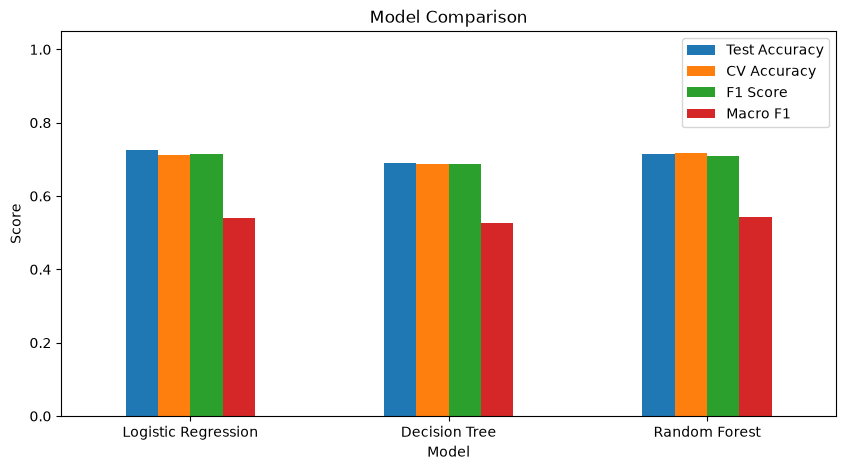

In [10]:
results_df[["Test Accuracy", "CV Accuracy", "F1 Score", "Macro F1"]].plot(
    kind="bar", figsize=(10, 5), rot=0
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.show()

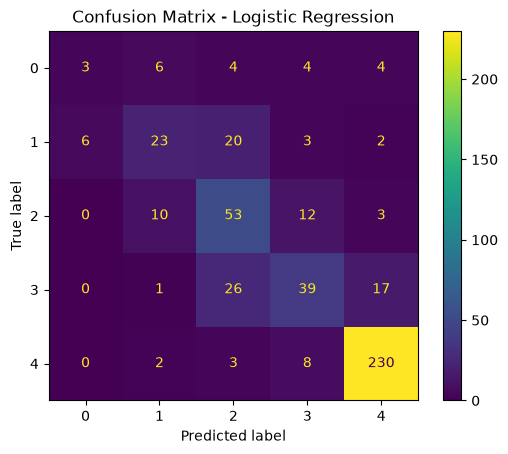

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, predictions["Logistic Regression"])

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

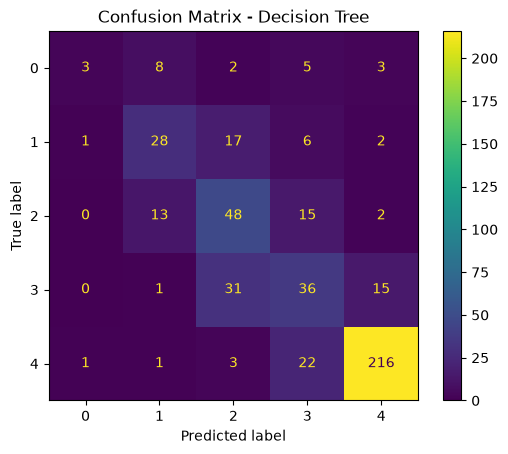

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, predictions["Decision Tree"])

plt.title("Confusion Matrix - Decision Tree")
plt.show()

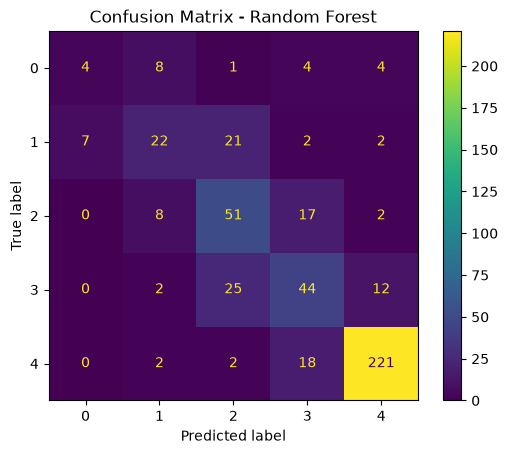

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test, predictions["Random Forest"])

plt.title("Confusion Matrix - Random Forest")
plt.show()

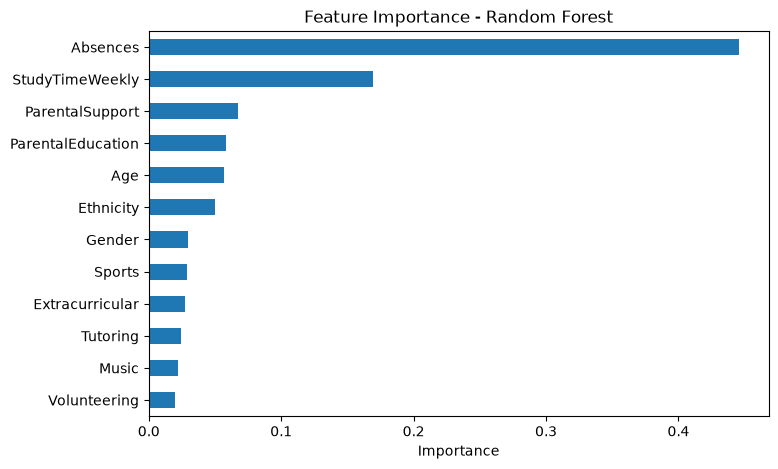

In [14]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()

importances.plot(kind="barh", figsize=(8, 5))

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

In [15]:
trained_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
}

best_name = results_df["Test Accuracy"].idxmax()
best_model = trained_models[best_name]

for name, row in results_df.iterrows():
    print(f"{name:<20} Test: {row['Test Accuracy'] * 100:.2f}%   CV: {row['CV Accuracy'] * 100:.2f}%")

print()
print("Best Model:", best_name)
print("Accuracy:", round(results_df.loc[best_name, "Test Accuracy"] * 100, 2), "%")

Logistic Regression  Test: 72.65%   CV: 71.30%
Decision Tree        Test: 69.10%   CV: 68.84%
Random Forest        Test: 71.40%   CV: 71.82%

Best Model: Logistic Regression
Accuracy: 72.65 %


In [16]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(X.columns.tolist(), "model_features.pkl")

print("Model saved as best_model.pkl")

Model saved as best_model.pkl
